In [1]:
from skykatana import SkyMaskPipe
from pathlib import Path
import healsparse as hsp
import healpy as hp
import lsdb
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.coordinates import SkyCoord, Angle
import astropy.units as u

from functools import partial
import pandas as pd
import gc


In [2]:
from rubin_scheduler.scheduler.utils import CurrentAreaMap



sag = CurrentAreaMap()
sky_maps, labels = sag.return_maps()

In [3]:
# Note: The Rubin footprint is selected in r-band
r_band_map = sky_maps['r']
i_band_map = sky_maps['i']


<Figure size 1000x600 with 0 Axes>

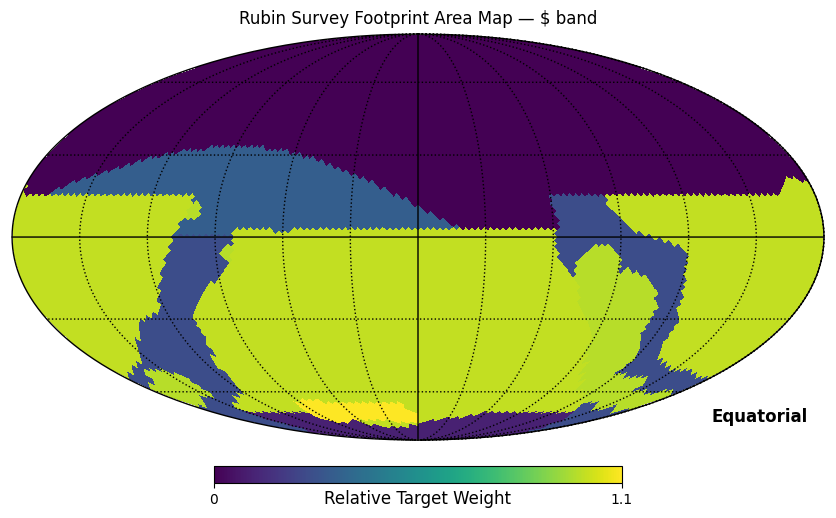

In [4]:
plt.figure(figsize=(10, 6))
hp.mollview(
    r_band_map,
    title=r"Rubin Survey Footprint Area Map — $ band",
    unit="Relative Target Weight",
    cmap="viridis",
    coord=["C"],  # Celestial / Equatorial coordinates (RA, Dec)
)
hp.graticule()
plt.show()


0 
1 LMC_SMC
2 bulgy
3 dusty_plane
4 euclid_overlap
5 lowdust
6 nes
7 scp
8 virgo


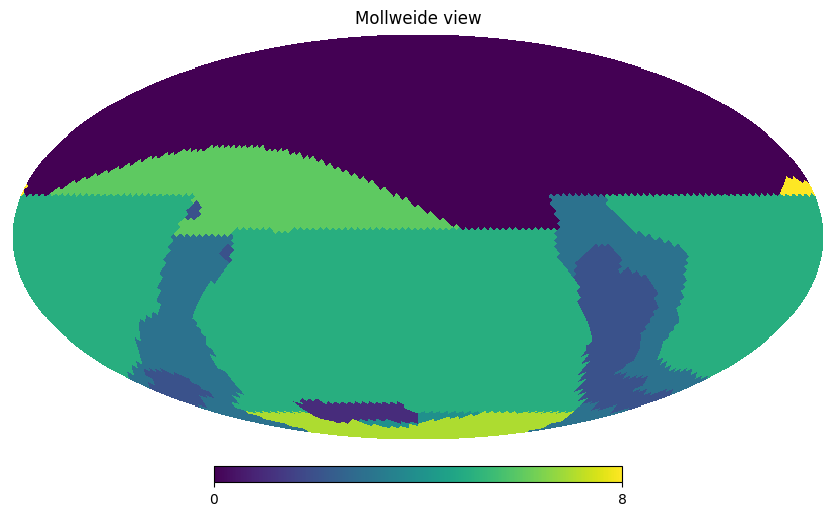

In [5]:
label_int = np.zeros(hp.nside2npix(32))
for i, label in enumerate(np.unique(labels)):
    label_int[labels == label] = i
    print(i, label)
hp.mollview(label_int)

In [6]:
idx = np.where(label_int > 3)[0]
idx[:10]

array([2779, 2780, 2781, 2782, 2783, 2784, 2785, 2786, 2787, 2788])

In [7]:
footprint_mask = hsp.HealSparseMap.make_empty(nside_coverage=2**3, nside_sparse=2**5, dtype=bool)
footprint_mask.update_values_pix(idx, True, nest=False)

In [8]:
# initialize and store in a skykatana stage
mkp = SkyMaskPipe()
mkp.allmask = footprint_mask

In [9]:
mkp.change_sparse_order(stage="allmask", order=8)

[change_sparse_order] allmask requested upgrade o5 → o8
[change_sparse_order] allmask done: o8 (NSIDE=256), cov=o3, n_valid=414,592, encoding=bool


HealSparseMap: nside_coverage = 8, nside_sparse = 256, bool, 414592 valid pixels

Retrieving pixels...
Found 414592 pixels
Creating display moc from pixels...
MOC max_order is 8 --> degrading to 7...
Drawing plot...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


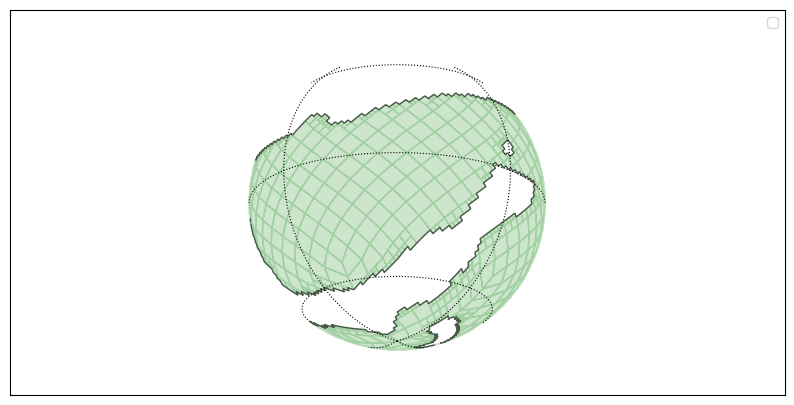

In [10]:
center = SkyCoord(150*u.deg, -20*u.deg, frame='icrs')   ;  fov = 150*u.deg
fig, ax, wcs = mkp.plot_moc(stage="allmask", center=center, fov=fov)
plt.legend()

In [11]:
# reading the monster catalog in hats format
!ls /media/mardom/megavault/data.lsdb.io/hats/the_monster/

/home/mardom/miniconda3/envs/lsdb_env-py313/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=288499) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


dataset  hats.properties  index.html  partition_info.csv  skymap.fits


In [12]:
import lsdb

catalog_path = "/media/mardom/megavault/data.lsdb.io/hats/the_monster/"
monster_cat = lsdb.read_hats(catalog_path)

# View catalog overview
print(monster_cat)

Dask NestedFrame Structure:
                                 id phot_g_mean_flux phot_bp_mean_flux phot_rp_mean_flux phot_g_mean_fluxErr phot_bp_mean_fluxErr phot_rp_mean_fluxErr     coord_raErr    coord_decErr            epoch            pm_ra           pm_dec        pm_raErr       pm_decErr         pm_flag         parallax      parallaxErr   parallax_flag coord_ra_coord_dec_Cov coord_ra_pm_ra_Cov coord_ra_pm_dec_Cov coord_ra_parallax_Cov coord_dec_pm_ra_Cov coord_dec_pm_dec_Cov coord_dec_parallax_Cov pm_ra_pm_dec_Cov pm_ra_parallax_Cov pm_dec_parallax_Cov astrometric_excess_noise monster_ComCam_g_flux monster_ComCam_g_fluxErr monster_ComCam_g_source_flag monster_ComCam_i_flux monster_ComCam_i_fluxErr monster_ComCam_i_source_flag monster_ComCam_r_flux monster_ComCam_r_fluxErr monster_ComCam_r_source_flag monster_ComCam_y_flux monster_ComCam_y_fluxErr monster_ComCam_y_source_flag monster_ComCam_z_flux monster_ComCam_z_fluxErr monster_ComCam_z_source_flag monster_DES_g_flux monster_DES_

In [13]:
cols = [
    "id", "ra", "dec",
    "phot_g_mean_flux",
    "monster_ComCam_r_flux", "monster_ComCam_r_fluxErr",
    "monster_ComCam_i_flux", "monster_ComCam_i_fluxErr",
    "parallax", "pm_ra", "pm_dec"
]

In [14]:
subset = monster_cat[cols].cone_search(ra=53.12, dec=-27.80, radius_arcsec=600)
df = subset.compute()
# 4. Filter for valid positive ComCam fluxes
valid_r = (df["monster_ComCam_r_flux"].notna()) & (df["monster_ComCam_r_flux"] > 0)
valid_i = (df["monster_ComCam_i_flux"].notna()) & (df["monster_ComCam_i_flux"] > 0)
# 5. Compute AB Magnitudes and Errors (AB zero-point = 31.40 for nJy)
df["ComCam_r_mag"] = np.nan
df["ComCam_r_mag_err"] = np.nan
df.loc[valid_r, "ComCam_r_mag"] = -2.5 * np.log10(df.loc[valid_r, "monster_ComCam_r_flux"]) + 31.40
df.loc[valid_r, "ComCam_r_mag_err"] = 1.0857 * (df.loc[valid_r, "monster_ComCam_r_fluxErr"] / df.loc[valid_r, "monster_ComCam_r_flux"])
df["ComCam_i_mag"] = np.nan
df["ComCam_i_mag_err"] = np.nan
df.loc[valid_i, "ComCam_i_mag"] = -2.5 * np.log10(df.loc[valid_i, "monster_ComCam_i_flux"]) + 31.40
df.loc[valid_i, "ComCam_i_mag_err"] = 1.0857 * (df.loc[valid_i, "monster_ComCam_i_fluxErr"] / df.loc[valid_i, "monster_ComCam_i_flux"])
# Compute r - i color
df["ComCam_r_minus_i"] = df["ComCam_r_mag"] - df["ComCam_i_mag"]

In [15]:
# Bright star radius function
# Magnitudes are in Gaia G-band (phot_g_mean_mag, Vega system)
# The exclusion radii correspond to the optical profile in Rubin r-band
def radfunction(df: pd.DataFrame, **kwargs):
    mag = 'phot_g_mean_mag'                          # Gaia G-band magnitude
    band = kwargs.get('band', 'r')                   # Target profile band (r-band)
    completeness = kwargs.get('completeness', 0.85)  # Completeness level

    if completeness == 0.85:
        if band == 'r':
            A = 1068.4259556870957
            B = -0.23979264155393915
            df['radius'] = A * np.exp(B * df[mag]) / 3600.0  # Radius in degrees
        elif band == 'r_halo':
            A1 = 11960.396409077423; B1 = -0.387584032932514
            A2 = 91530.48016015181;  B2 = -0.5364916773790975
            A3 = 1068.4259556870816; B3 = -0.23979264155393853
            th1 = 13.666666666666666
            th2 = 15.0
            conditions = [
                df[mag] < th1,
                (df[mag] >= th1) & (df[mag] < th2),
                df[mag] >= th2
            ]
            funcs = [
                A1 * np.exp(B1 * df[mag]) / 3600.0,
                A2 * np.exp(B2 * df[mag]) / 3600.0,
                A3 * np.exp(B3 * df[mag]) / 3600.0
            ]
            df['radius'] = np.select(conditions, funcs)
        elif band == 'g':
            A = 1143.921; B = -0.241
            df['radius'] = A * np.exp(B * df[mag]) / 3600.0
        elif band == 'i':
            A = 1056.128; B = -0.245
            df['radius'] = A * np.exp(B * df[mag]) / 3600.0


In [16]:
# Magnitude limits in Gaia G-band (Vega system)
# TIP: For bright star masking, stars with G in [-2.5, 14.0] or [-2.5, 16.0] are typical,
# as stars fainter than G ~ 15 have negligible halo contamination.
maglims = [-2.5, 15.0]
outfile = 'WideFastDeep-r'

starq = {
    'search_stage': mkp.allmask,                  # Base WFD footprint stage
    'cat': catalog_path,                         # Path to The Monster HATS catalog
    'columns': ['ra', 'dec', 'phot_g_mean_flux'],# Gaia G-band flux in nJy
    'gaia_gmag_lims': maglims,                   # Gaia G magnitude limits
    'radfunction': partial(radfunction, completeness=0.85, band='r'),  # r-band star mask
    'avoid_mw': True,                            # Avoid Galactic plane & bulge
    'b0_deg': 5.0,                              # Milky Way exclusion zone +/- b (deg)
    'bulge_a_deg': 5.0,                         # Milky Way bulge semimajor axis (deg)
    'bulge_b_deg':  3.0,                         # Milky Way bulge semiminor axis (deg)
    'max_area_single': 400.0,                    # Max area for single query (deg^2)
    'target_chunk_area': 400.0,                  # Target chunk area (deg^2)
    'coarse_order_bfs': 5                        # Coarse order for MOC chunking
}


In [17]:
# ==============================================================================
# Corrected Bright Star Mask Builder for The Monster (DMTN-277)
# Note: The Monster stores all fluxes in nanoJanskys (nJy), NOT e-/s.
# Gaia DR3 flux (e-/s) * 174.840 = Monster phot_g_mean_flux (nJy).
# Zero Point conversion to Gaia G (Vega):
#   G = -2.5 * log10(phot_g_mean_flux) + 31.2940  (instead of +25.6874)
# ==============================================================================
ZP_MONSTER_GAIA_G = 31.2940

def build_star_mask_online_monster(self, starq, order_sparse=None, order_cov=None,
                                   columns=None, save_stars=False, bit_packed=True,
                                   n_threads=16, chunk_size=600000, output_stage=None,
                                   mwmask_output_stage=None):
    from lsdb.core.search.region_search import MOCSearch
    from skykatana.skykatana import getarea_moc, split_moc_into_chunks
    from mocpy import MOC
    import gc

    print('BUILDING STAR MASK (The Monster HATS streaming) >>>>>>>>>>>>>>>>>>>>>')
    ord_cov = order_cov if order_cov is not None else self.order_cov
    ord_sp = order_sparse if order_sparse is not None else self.order_out
    nside_sparse = 1 << ord_sp
    nside_cov = 1 << ord_cov
    mask = hsp.HealSparseMap.make_empty(nside_cov, nside_sparse, dtype=np.bool_, bit_packed=True)

    MAX_DEPTH = 8
    search_stage = starq['search_stage']
    order_search_stg = int(np.log2(search_stage.nside_sparse))
    moc = MOC.from_healpix_cells(ipix=search_stage.valid_pixels, depth=order_search_stg, max_depth=MAX_DEPTH)

    # Milky Way exclusion if requested
    if starq.get('avoid_mw', False):
        moc_pb = SkyMaskPipe.gal_plane_bulge_moc(
            max_depth=MAX_DEPTH,
            b0_deg=starq.get('b0_deg', 10.0),
            bulge_a_deg=starq.get('bulge_a_deg', 15.0),
            bulge_b_deg=starq.get('bulge_b_deg', 10.0)
        )
        moc = moc.difference(moc_pb)

    # 1. Convert Gaia G magnitude limits to flux limits in nJy using ZP = 31.2940
    g_min, g_max = starq['gaia_gmag_lims']
    flux_min = 10 ** ((ZP_MONSTER_GAIA_G - g_max) / 2.5)
    flux_max = 10 ** ((ZP_MONSTER_GAIA_G - g_min) / 2.5)

    cols = ['ra', 'dec', 'phot_g_mean_flux']
    cat_filters = [['phot_g_mean_flux', '>=', flux_min], ['phot_g_mean_flux', '<=', flux_max]]
    print(f"--- Corrected Gaia G flux limits (ZP={ZP_MONSTER_GAIA_G}): [{flux_min:,.1f}, {flux_max:,.1f}] nJy for G in [{g_min}, {g_max}]")

    cat_path = starq['cat']
    if hasattr(cat_path, 'catalog_path'):
        cat_path = cat_path.catalog_path
    elif hasattr(cat_path, 'catalog_base_dir'):
        cat_path = cat_path.catalog_base_dir

    gaia = lsdb.open_catalog(cat_path, columns=cols, search_filter=MOCSearch(moc), filters=cat_filters)

    # 2. Split MOC into chunks to handle massive footprints safely
    max_area_sing = starq.get('max_area_single', 400.0)
    target_chunk_area = starq.get('target_chunk_area', 400.0)
    coarse_order_bfs = starq.get('coarse_order_bfs', 5)
    moc_area = getarea_moc(moc)
    if moc_area < max_area_sing:
        chunk_mocs = [moc.add_neighbours()]
    else:
        chunk_mocs = split_moc_into_chunks(moc, target_deg2=target_chunk_area, coarse_order=coarse_order_bfs)
        chunk_mocs = [c.intersection(moc).add_neighbours() for c in chunk_mocs]
    print(f"Total chunks to stream: {len(chunk_mocs)}")

    radfunction = starq['radfunction']

    # 3. Stream each chunk, compute true Gaia G magnitude from nJy flux, compute r-band radii, and pixelate
    for i, mi in enumerate(chunk_mocs, 1):
        print(f"Chunk {i}/{len(chunk_mocs)} querying...")
        s = gaia.moc_search(moc=mi).compute()
        print(f"--- Stars in chunk: {len(s):,}")
        if len(s) == 0:
            continue

        # Correct conversion from The Monster nJy flux to Gaia G mag (Vega)
        s['phot_g_mean_mag'] = -2.5 * np.log10(s['phot_g_mean_flux']) + ZP_MONSTER_GAIA_G

        # Apply radius function (model in r-band based on Gaia G magnitude)
        radfunction(s)

        if save_stars:
            s[['ra', 'dec', 'phot_g_mean_mag', 'radius']].to_parquet(f"stars_chunk_{i}.parquet")

        # Pixelate circles into the sparse mask
        self.pixelate_circles(s, mask, order=ord_sp, columns=['ra', 'dec', 'radius'],
                              n_threads=n_threads, chunk_size=chunk_size)
        del s
        gc.collect()

    if bit_packed:
        mask = mask.as_bit_packed_map()

    self.starmask = mask
    return mask


In [18]:
# ==============================================================================
# Dask Distributed Cluster Initialization
# Optimized for: Intel Core Ultra 9 275HX (24 cores) & 62 GiB RAM
#   - 4 worker processes x 4 threads = 16 threads for parallel catalog queries
#   - 12 GiB memory limit per worker = 48 GiB total (leaves ~14 GiB for OS/HealSparse)
# ==============================================================================
from dask.distributed import Client

# Close existing client if one was running
try:
    client.close()
except Exception:
    pass

client = Client(
    n_workers=4,
    threads_per_worker=4,
    memory_limit='12GiB'
)

print('Dask Dashboard URL:', client.dashboard_link)
client


Dask Dashboard URL: http://127.0.0.1:8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 48.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44749,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:32867,Total threads: 4
Dashboard: http://127.0.0.1:36327/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:39241,


In [19]:
# Apply the patch to SkyMaskPipe and execute
SkyMaskPipe.build_star_mask_online = build_star_mask_online_monster
mkp.build_star_mask_online(starq=starq, order_sparse=15, order_cov=5, n_threads=16, save_stars=False);


BUILDING STAR MASK (The Monster HATS streaming) >>>>>>>>>>>>>>>>>>>>>
--- Corrected Gaia G flux limits (ZP=31.294): [3,293,062.7, 32,930,627,017,520.7] nJy for G in [-2.5, 15.0]
Total chunks to stream: 65
Chunk 1/65 querying...
--- Stars in chunk: 91,860
--- Pixelating circles from DataFrame
    Order :: 15 | pixelization_threads=16
    Circles to pixelate: 91860 in batches of 600000
        processing circles 0:91860 ...
Chunk 2/65 querying...
--- Stars in chunk: 139,664
--- Pixelating circles from DataFrame
    Order :: 15 | pixelization_threads=16
    Circles to pixelate: 139664 in batches of 600000
        processing circles 0:139664 ...
Chunk 3/65 querying...
--- Stars in chunk: 131,326
--- Pixelating circles from DataFrame
    Order :: 15 | pixelization_threads=16
    Circles to pixelate: 131326 in batches of 600000
        processing circles 0:131326 ...
Chunk 4/65 querying...
--- Stars in chunk: 169,769
--- Pixelating circles from DataFrame
    Order :: 15 | pixelization_thread

In [20]:
# Combine: Base WFD footprint minus bright star mask
mkp.combine(positive=['allmask'], negative=['starmask'], verbose=True)

# Save to disk as WideFastDeep-r
mkp.write('./WideFastDeep-r', overwrite=True)
print('Saved WideFastDeep-r mask successfully to disk!')


[combine] aligning coverage for 'allmask' : c3 → c4
[combine] aligning coverage for 'starmask' : c5 → c4
[combine] target=(o15, c4), work_order=8, r2=16384
[combine:+] stage at order 8 -> work 8
[combine] done: order_out=15 (NSIDE=32768), order_cov=4 (NSIDE=16), valid_pix=5,075,848,771, area=16251.097 deg², bit_packed=True
Saved WideFastDeep-r mask successfully to disk!


In [21]:
print(f"Base Footprint valid area : {mkp.allmask.get_valid_area(degrees=True):,.2f} deg^2")
print(f"Bright Star Mask area     : {mkp.starmask.get_valid_area(degrees=True):,.2f} deg^2")
print(f"Final Combined Mask area   : {mkp.mask.get_valid_area(degrees=True):,.2f} deg^2")


Base Footprint valid area : 21,747.78 deg^2
Bright Star Mask area     : 5,498.74 deg^2
Final Combined Mask area   : 16,251.10 deg^2


In [22]:
# Hereafter, clean all and read from file the WideFastDeep-r mask

In [23]:
from skykatana import SkyMaskPipe
mkp = SkyMaskPipe()
fwd = mkp.read("./WideFastDeep-r")

[read] Loading allmask  <- allmask.fits
[read] Loading mask  <- mask.fits
[read] Loading starmask  <- starmask.fits
[read] Done  allmask  (nside_cov=8, nside_sparse=256, n_valid=414592)
[read] Done  starmask  (nside_cov=32, nside_sparse=32768, n_valid=1717469809)
[read] Done  mask  (nside_cov=16, nside_sparse=32768, n_valid=5075848771)
[read] All stages attached.


Retrieving pixels inside clip box...
Found 83113 pixels
Creating display moc from pixels...
MOC max_order is 15 --> no degrading...
Drawing plot...


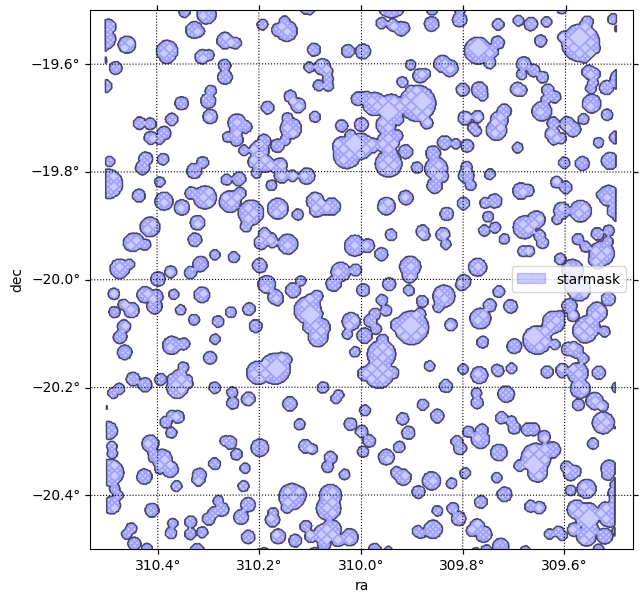

In [24]:
center = SkyCoord(310*u.deg, -20*u.deg)  ;  fov = 1*u.deg
clipra  = [310-0.5, 310+0.5]
clipdec = [-20-0.5, -20+0.5]
fig, ax, wcs = fwd.plot_moc(stage='starmask', center=center, fov=fov, figsize=[7,7], label='starmask', color='b',
                            clipra=clipra, clipdec=clipdec)
plt.legend();

Fractions at edge pixels are being averaged
Fractional area map created at order 8: 411376 valid pixels


/home/mardom/miniconda3/envs/lsdb_env-py313/lib/python3.13/site-packages/skykatana/skykatana.py:2905: RuntimeWarning: invalid value encountered in divide
  arr_for = np.where(den > 0, num/den, np.nan)


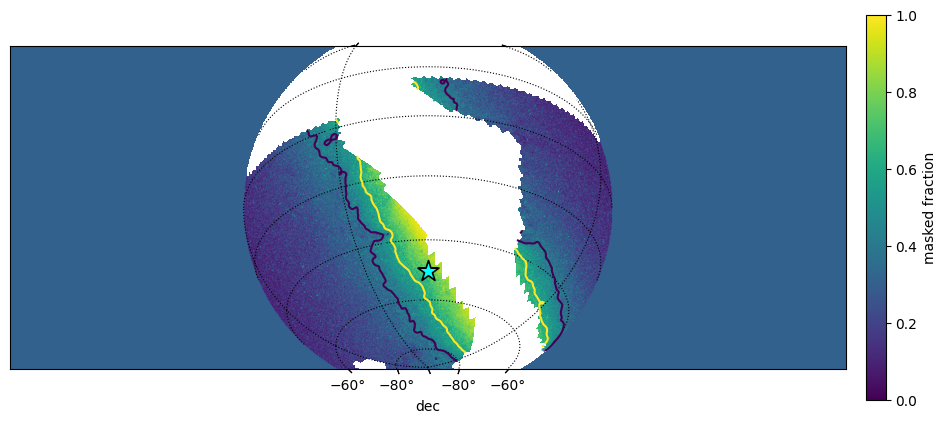

In [47]:
center = SkyCoord(270*u.deg, -30*u.deg)  ;  fov = 100*u.deg
fig, ax, wcs, im, cs = fwd.plot_fracmap(stage='starmask', center=center, fov=fov, figsize=[13,5], order_frac=8, avg_edges=True, 
                                        thresholds=[0.4, 0.5, 0.6], contour_smooth={'method':'gaussian', 'sigma_pix':3.0})
# 2. Define your target coordinate
target = SkyCoord(ra=270*u.deg, dec=-50*u.deg)
# 3. Add a marker (e.g. star, cross, circle)
ax.scatter(
    target.ra.deg, 
    target.dec.deg, 
    transform=ax.get_transform('world'), 
    color='cyan', 
    marker='*', 
    s=250, 
    edgecolor='black', 
    linewidth=1.2,
    zorder=10, 
    label='Target'
)


Retrieving pixels inside clip box...
Found 150956 pixels
Creating display moc from pixels...
MOC max_order is 15 --> no degrading...
Drawing plot...


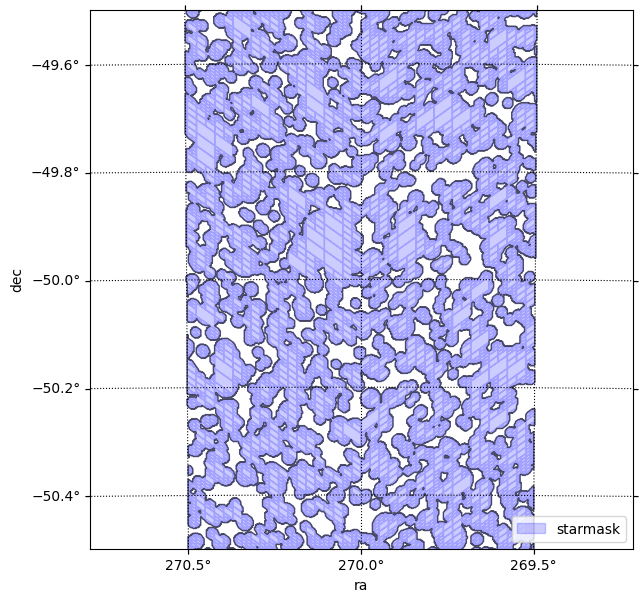

In [40]:
center = SkyCoord(270*u.deg, -50*u.deg)  ;  fov = 1*u.deg
clipra  = [270-0.5, 270+0.5]
clipdec = [-50-0.5, -50+0.5]
fig, ax, wcs = fwd.plot_moc(stage='starmask', center=center, fov=fov, figsize=[7,7], label='starmask', color='b',
                            clipra=clipra, clipdec=clipdec)
plt.legend();

Fractions at edge pixels are being averaged
Fractional area map created at order 8: 411376 valid pixels


/home/mardom/miniconda3/envs/lsdb_env-py313/lib/python3.13/site-packages/skykatana/skykatana.py:2905: RuntimeWarning: invalid value encountered in divide
  arr_for = np.where(den > 0, num/den, np.nan)


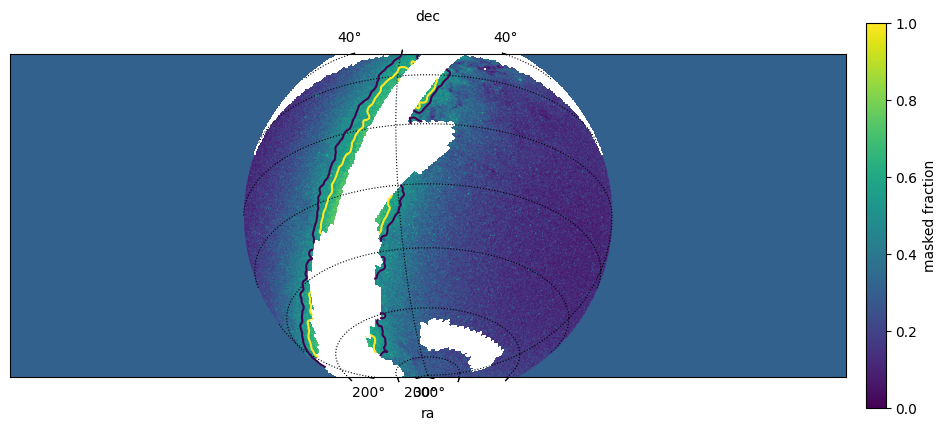

In [37]:
center = SkyCoord(90*u.deg, -30*u.deg)  ;  fov = 100*u.deg
fig, ax, wcs, im, cs = fwd.plot_fracmap(stage='starmask', center=center, fov=fov, figsize=[13,5], order_frac=8, avg_edges=True, 
                                        thresholds=[0.5, 0.6], contour_smooth={'method':'gaussian', 'sigma_pix':3.0})

In [46]:
# 1. Generate fractional map (order 8 matches plot_fracmap default)
order_frac = 8
frac_map = SkyMaskPipe.frac_area_map(fwd.starmask, order_frac=order_frac, avg_edges=True)
# 2. Extract HEALPix values and exact pixel area
nside = 2**order_frac
vals = frac_map.generate_healpix_map(nside=nside, nest=True).astype(float)
pix_area_deg2 = hp.nside2pixarea(nside, degrees=True)
# 3. Valid pixels within footprint
valid = (vals != hp.UNSEEN) & np.isfinite(vals)
total_area = np.sum(valid) * pix_area_deg2
area_gt_05 = np.sum(valid & (vals > 0.5)) * pix_area_deg2
area_gt_55 = np.sum(valid & (vals > 0.55)) * pix_area_deg2
area_gt_06 = np.sum(valid & (vals > 0.6)) * pix_area_deg2
print(f"Total footprint area:         {total_area:.2f} deg²")
print(f"Area with masked frac > 0.5:  {area_gt_05:.2f} deg² ({100 * area_gt_05 / total_area:.2f}%)")
print(f"Area with masked frac > 0.55:  {area_gt_55:.2f} deg² ({100 * area_gt_55 / total_area:.2f}%)")
print(f"Area with masked frac > 0.6:  {area_gt_06:.2f} deg² ({100 * area_gt_06 / total_area:.2f}%)")

Fractions at edge pixels are being averaged
Fractional area map created at order 8: 411376 valid pixels
Total footprint area:         21579.08 deg²
Area with masked frac > 0.5:  2240.39 deg² (10.38%)
Area with masked frac > 0.55:  1643.28 deg² (7.62%)
Area with masked frac > 0.6:  1174.28 deg² (5.44%)


Fractions at edge pixels are being averaged
Fractional area map created at order 8: 411376 valid pixels


/home/mardom/miniconda3/envs/lsdb_env-py313/lib/python3.13/site-packages/skykatana/skykatana.py:2905: RuntimeWarning: invalid value encountered in divide
  arr_for = np.where(den > 0, num/den, np.nan)


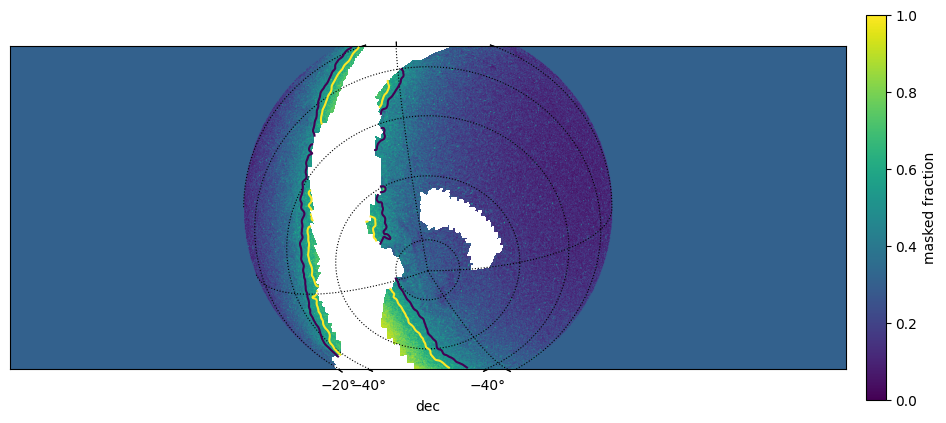

In [44]:

center = SkyCoord(90*u.deg, -70*u.deg)  ;  fov = 100*u.deg
fig, ax, wcs, im, cs = fwd.plot_fracmap(stage='starmask', center=center, fov=fov, figsize=[13,5], order_frac=8, avg_edges=True, 
                                        thresholds=[0.5, 0.6], contour_smooth={'method':'gaussian', 'sigma_pix':3.0})

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.ndimage import gaussian_filter
import astropy.units as u
from astropy.coordinates import SkyCoord
import healpy as hp

# ==============================================================================
# 1. Access Dust Map E(B-V)
# ==============================================================================
dust_hp = getattr(sag, 'dustmap', getattr(sag, 'dust_map', None))
if dust_hp is None:
    try:
        from rubin_scheduler.scheduler.utils import read_fields
        dust_hp = read_fields.read_dust_map()
    except Exception:
        pass
if dust_hp is None:
    try:
        import dustmaps.sfd
        sfd = dustmaps.sfd.SFDQuery()
    except Exception:
        sfd = None
else:
    sfd = None

if dust_hp is not None:
    nside_dust = hp.npix2nside(len(dust_hp))
    pix_gc_gal = hp.ang2pix(nside_dust, 0.0, 0.0, lonlat=True)
    c_gc = SkyCoord(l=0.0*u.deg, b=0.0*u.deg, frame='galactic')
    pix_gc_eq = hp.ang2pix(nside_dust, c_gc.icrs.ra.deg, c_gc.icrs.dec.deg, lonlat=True)
    dust_is_galactic = (dust_hp[pix_gc_gal] > dust_hp[pix_gc_eq])
    print(f"Dust map detected: NSIDE={nside_dust}, frame={'Galactic' if dust_is_galactic else 'Equatorial'}")

# ==============================================================================
# 2. Downsample to NSIDE=64 for Smooth, Continuous Mask Boundaries
# ==============================================================================
# Coarser pixel scale (~0.9 deg) averages over small individual bright star halos,
# eliminating isolated 1-pixel noise fragments so contour lines remain continuous.
nside_low = 64
order_low = int(np.log2(nside_low))
pix_area_low = hp.nside2pixarea(nside_low, degrees=True)
npix_low = hp.nside2npix(nside_low)

allmask_hp_256 = fwd.allmask.generate_healpix_map(nside=256, nest=True)

# Nested subpixel averaging (ratio = 16 subpixels per parent pixel)
ratio = (256 // nside_low) ** 2
footprint_low_frac = allmask_hp_256.reshape(-1, ratio).mean(axis=1)
footprint_low = (footprint_low_frac >= 0.5)

vals_clean = np.where(vals == hp.UNSEEN, 1.0, np.nan_to_num(vals, nan=1.0))
vals_low = vals_clean.reshape(-1, ratio).mean(axis=1)

theta_low, phi_low = hp.pix2ang(nside_low, np.arange(npix_low), nest=True)
ra_low = np.degrees(phi_low)
dec_low = 90.0 - np.degrees(theta_low)

if dust_hp is not None:
    if dust_is_galactic:
        c_low = SkyCoord(ra=ra_low*u.deg, dec=dec_low*u.deg, frame='icrs').galactic
        pix_d_low = hp.ang2pix(nside_dust, c_low.l.deg, c_low.b.deg, lonlat=True)
    else:
        pix_d_low = hp.ang2pix(nside_dust, ra_low, dec_low, lonlat=True)
    ebv_low = dust_hp[pix_d_low]
elif sfd is not None:
    ebv_low = sfd(SkyCoord(ra=ra_low*u.deg, dec=dec_low*u.deg, frame='icrs').galactic)
else:
    ebv_low = np.zeros(npix_low)

# Areas at order 6
area_base_wfd = np.sum(footprint_low) * pix_area_low
area_ebv_008  = np.sum(footprint_low & (ebv_low <= 0.08)) * pix_area_low
area_comp_50  = np.sum(footprint_low & (vals_low <= 0.50)) * pix_area_low
area_comp_55  = np.sum(footprint_low & (vals_low <= 0.55)) * pix_area_low
area_comp_60  = np.sum(footprint_low & (vals_low <= 0.60)) * pix_area_low

print("=" * 65)
print(f"{'CUT / MASK':<38} | {'GROSS AREA [deg²]':<16} | {'SHARE [%]':<10}")
print("=" * 65)
print(f"{'Base WFD (E(B-V) <= 0.12)':<38} | {area_base_wfd:10.1f} deg²  | 100.00%")
print(f"{'Strict Dust (E(B-V) <= 0.08)':<38} | {area_ebv_008:10.1f} deg²  | {100*area_ebv_008/area_base_wfd:6.2f}%")
print(f"{'Completeness > 0.50 (f_mask <= 0.50)':<38} | {area_comp_50:10.1f} deg²  | {100*area_comp_50/area_base_wfd:6.2f}%")
print(f"{'Completeness > 0.55 (f_mask <= 0.55)':<38} | {area_comp_55:10.1f} deg²  | {100*area_comp_55/area_base_wfd:6.2f}%")
print(f"{'Completeness > 0.60 (f_mask <= 0.60)':<38} | {area_comp_60:10.1f} deg²  | {100*area_comp_60/area_base_wfd:6.2f}%")
print("=" * 65)

# ==============================================================================
# 3. Contour Extraction Filtering Jumps > 1.0 Degree
# ==============================================================================
def get_clean_boundary_lines(lon_grid, lat_grid, field_smoothed, coord_type="equatorial_mollweide", max_dist_deg=1.0):
    """
    Extracts contour paths and guarantees that NO two points separated by more
    than max_dist_deg (1.0 degree) are ever connected.
    Supports:
      - 'equatorial_mollweide' (or True)
      - 'galactic_mollweide' (or False)
      - 'cartesian' (or 'zoom')
    """
    fig_tmp, ax_tmp = plt.subplots()
    cs = ax_tmp.contour(lon_grid, lat_grid, field_smoothed, levels=[0.5])
    plt.close(fig_tmp)

    raw_segs = []
    if hasattr(cs, 'get_paths'):
        for path in cs.get_paths():
            for poly in path.to_polygons():
                if len(poly) >= 2:
                    raw_segs.append(poly)
    if not raw_segs and hasattr(cs, 'allsegs') and len(cs.allsegs) > 0:
        for seg in cs.allsegs[0]:
            if len(seg) >= 2:
                raw_segs.append(seg)

    clean_subsegments = []
    for seg in raw_segs:
        lons = seg[:, 0]
        lats = seg[:, 1]

        # Convert to plot coordinates
        if coord_type in (True, "equatorial_mollweide"):
            x_plot = -np.radians(lons - 180.0)
            y_plot = np.radians(lats)
            is_mollweide = True
        elif coord_type in (False, "galactic_mollweide"):
            x_plot = -np.radians(lons)
            y_plot = np.radians(lats)
            is_mollweide = True
        elif coord_type in ("cartesian", "zoom"):
            x_plot = lons
            y_plot = lats
            is_mollweide = False
        else:
            raise ValueError(f"Unknown coord_type: {coord_type}")

        # Great-circle angular distance between consecutive points on the sphere
        r_lon1 = np.radians(lons[:-1])
        r_lat1 = np.radians(lats[:-1])
        r_lon2 = np.radians(lons[1:])
        r_lat2 = np.radians(lats[1:])

        dlon = r_lon2 - r_lon1
        dlat = r_lat2 - r_lat1
        a = np.sin(dlat / 2.0)**2 + np.cos(r_lat1) * np.cos(r_lat2) * np.sin(dlon / 2.0)**2
        a = np.clip(a, 0.0, 1.0)
        sph_dists_deg = np.degrees(2.0 * np.arcsin(np.sqrt(a)))

        # Also check 2D plot coordinate jump
        dx = np.abs(x_plot[1:] - x_plot[:-1])
        dy = np.abs(y_plot[1:] - y_plot[:-1])
        if is_mollweide:
            plot_dists_deg = np.degrees(np.sqrt(dx**2 + dy**2))
        else:
            plot_dists_deg = np.sqrt(dx**2 + dy**2)

        # Split wherever distance > max_dist_deg (1.0 degree)
        jumps = np.where((sph_dists_deg > max_dist_deg) | (plot_dists_deg > max_dist_deg))[0]

        if len(jumps) > 0:
            split_idx = jumps + 1
            sub_xs = np.split(x_plot, split_idx)
            sub_ys = np.split(y_plot, split_idx)
            for sx, sy in zip(sub_xs, sub_ys):
                if len(sx) >= 3:
                    clean_subsegments.append((sx, sy))
        else:
            if len(x_plot) >= 3:
                clean_subsegments.append((x_plot, y_plot))

    return clean_subsegments

# ==============================================================================
# 4. High-Contrast Line Styling
# ==============================================================================
color_comp_50 = "#00cc44"  # Green line
color_comp_55 = "#0066ff"  # Blue line
color_comp_60 = "#ee2222"  # Red line
color_base    = "#111111"  # Dark base boundary
color_dust08  = "#ff9900"  # Amber dust boundary

legend_handles = [
    mlines.Line2D([], [], color=color_comp_50, lw=2.8, ls="-", label=f"Completeness > 0.50 (f_mask ≤ 0.50): {area_comp_50:,.0f} deg²"),
    mlines.Line2D([], [], color=color_comp_55, lw=2.8, ls="-", label=f"Completeness > 0.55 (f_mask ≤ 0.55): {area_comp_55:,.0f} deg²"),
    mlines.Line2D([], [], color=color_comp_60, lw=2.8, ls="-", label=f"Completeness > 0.60 (f_mask ≤ 0.60): {area_comp_60:,.0f} deg²"),
    mlines.Line2D([], [], color=color_base,    lw=2.2, ls="--", label=f"Base WFD ($E(B-V) \\leq 0.12$): {area_base_wfd:,.0f} deg²"),
    mlines.Line2D([], [], color=color_dust08,  lw=2.2, ls="--", label=f"Strict Dust ($E(B-V) \\leq 0.08$): {area_ebv_008:,.0f} deg²")
]

# ==============================================================================
# PLOT 1: Equatorial Mollweide Projection (Max Distance <= 1.0 deg)
# ==============================================================================
print("Extracting Equatorial boundary lines (enforcing max distance <= 1.0 deg)...")
ra_eq_vals = np.linspace(0.0, 360.0, 721)
dec_eq_vals = np.linspace(-90.0, 90.0, 361)
RA_eq, DEC_eq = np.meshgrid(ra_eq_vals, dec_eq_vals)

pix_eq_eval = hp.ang2pix(nside_low, RA_eq, DEC_eq, lonlat=True, nest=True)
grid_wfd_eq = footprint_low[pix_eq_eval]
grid_frac_eq = vals_low[pix_eq_eval]
grid_ebv_eq = ebv_low[pix_eq_eval]

sigma_contour = 3.2
sm_wfd_eq = gaussian_filter(grid_wfd_eq.astype(float), sigma=sigma_contour)
sm_d08_eq = gaussian_filter((grid_wfd_eq & (grid_ebv_eq <= 0.08)).astype(float), sigma=sigma_contour)
sm_c50_eq = gaussian_filter((grid_wfd_eq & (grid_frac_eq <= 0.50)).astype(float), sigma=sigma_contour)
sm_c55_eq = gaussian_filter((grid_wfd_eq & (grid_frac_eq <= 0.55)).astype(float), sigma=sigma_contour)
sm_c60_eq = gaussian_filter((grid_wfd_eq & (grid_frac_eq <= 0.60)).astype(float), sigma=sigma_contour)

lines_wfd_eq = get_clean_boundary_lines(RA_eq, DEC_eq, sm_wfd_eq, coord_type="equatorial_mollweide", max_dist_deg=1.0)
lines_d08_eq = get_clean_boundary_lines(RA_eq, DEC_eq, sm_d08_eq, coord_type="equatorial_mollweide", max_dist_deg=1.0)
lines_c50_eq = get_clean_boundary_lines(RA_eq, DEC_eq, sm_c50_eq, coord_type="equatorial_mollweide", max_dist_deg=1.0)
lines_c55_eq = get_clean_boundary_lines(RA_eq, DEC_eq, sm_c55_eq, coord_type="equatorial_mollweide", max_dist_deg=1.0)
lines_c60_eq = get_clean_boundary_lines(RA_eq, DEC_eq, sm_c60_eq, coord_type="equatorial_mollweide", max_dist_deg=1.0)

x_eq = -np.radians(RA_eq - 180.0)
y_eq = np.radians(DEC_eq)

fig1 = plt.figure(figsize=(14, 8), dpi=150)
ax1 = fig1.add_subplot(111, projection='mollweide')

# Grayscale dust background
im1 = ax1.pcolormesh(
    x_eq, y_eq, np.log10(np.clip(grid_ebv_eq, 0.01, 10.0)),
    cmap="Greys", vmin=np.log10(0.02), vmax=np.log10(1.5),
    shading="auto", alpha=0.55
)

cbar1 = plt.colorbar(im1, ax=ax1, orientation="horizontal", pad=0.08, shrink=0.55)
cbar1.set_label(r"$\log_{10}(E(B-V)_{\rm SFD})$ [mag]", fontsize=11)

# Plot segments ensuring NO two points > 1 deg are ever connected
for sx, sy in lines_wfd_eq:
    ax1.plot(sx, sy, color=color_base, lw=2.2, ls="--")
for sx, sy in lines_d08_eq:
    ax1.plot(sx, sy, color=color_dust08, lw=2.2, ls="--")
for sx, sy in lines_c50_eq:
    ax1.plot(sx, sy, color=color_comp_50, lw=2.8, ls="-")
for sx, sy in lines_c55_eq:
    ax1.plot(sx, sy, color=color_comp_55, lw=2.8, ls="-")
for sx, sy in lines_c60_eq:
    ax1.plot(sx, sy, color=color_comp_60, lw=2.8, ls="-")

ra_ticks_deg = np.array([300, 240, 180, 120, 60])
ax1.set_xticks(-np.radians(ra_ticks_deg - 180.0))
ax1.set_xticklabels([f"{ra}°" for ra in ra_ticks_deg])
ax1.grid(True, color="gray", linestyle=":", linewidth=0.7, alpha=0.5)

ax1.set_title("Rubin Survey Mask Boundaries in Equatorial Mollweide Projection", fontsize=13, pad=16, fontweight="bold")
ax1.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.96), frameon=True, framealpha=0.94, fontsize=9.5)
plt.tight_layout()
plt.show()

# ==============================================================================
# PLOT 2: Galactic Mollweide Projection (Max Distance <= 1.0 deg)
# ==============================================================================
print("Extracting Galactic boundary lines (enforcing max distance <= 1.0 deg)...")
l_gal_vals = np.linspace(-180.0, 180.0, 721)
b_gal_vals = np.linspace(-90.0, 90.0, 361)
L_gal, B_gal = np.meshgrid(l_gal_vals, b_gal_vals)

c_gal_grid = SkyCoord(l=L_gal*u.deg, b=B_gal*u.deg, frame='galactic').icrs
pix_gal_eval = hp.ang2pix(nside_low, c_gal_grid.ra.deg, c_gal_grid.dec.deg, lonlat=True, nest=True)

grid_wfd_gal = footprint_low[pix_gal_eval]
grid_frac_gal = vals_low[pix_gal_eval]
grid_ebv_gal = ebv_low[pix_gal_eval]

sm_wfd_gal = gaussian_filter(grid_wfd_gal.astype(float), sigma=sigma_contour)
sm_d08_gal = gaussian_filter((grid_wfd_gal & (grid_ebv_gal <= 0.08)).astype(float), sigma=sigma_contour)
sm_c50_gal = gaussian_filter((grid_wfd_gal & (grid_frac_gal <= 0.50)).astype(float), sigma=sigma_contour)
sm_c55_gal = gaussian_filter((grid_wfd_gal & (grid_frac_gal <= 0.55)).astype(float), sigma=sigma_contour)
sm_c60_gal = gaussian_filter((grid_wfd_gal & (grid_frac_gal <= 0.60)).astype(float), sigma=sigma_contour)

lines_wfd_gal = get_clean_boundary_lines(L_gal, B_gal, sm_wfd_gal, coord_type="galactic_mollweide", max_dist_deg=1.0)
lines_d08_gal = get_clean_boundary_lines(L_gal, B_gal, sm_d08_gal, coord_type="galactic_mollweide", max_dist_deg=1.0)
lines_c50_gal = get_clean_boundary_lines(L_gal, B_gal, sm_c50_gal, coord_type="galactic_mollweide", max_dist_deg=1.0)
lines_c55_gal = get_clean_boundary_lines(L_gal, B_gal, sm_c55_gal, coord_type="galactic_mollweide", max_dist_deg=1.0)
lines_c60_gal = get_clean_boundary_lines(L_gal, B_gal, sm_c60_gal, coord_type="galactic_mollweide", max_dist_deg=1.0)

x_gal = -np.radians(L_gal)
y_gal = np.radians(B_gal)

fig2 = plt.figure(figsize=(14, 8), dpi=150)
ax2 = fig2.add_subplot(111, projection='mollweide')

im2 = ax2.pcolormesh(
    x_gal, y_gal, np.log10(np.clip(grid_ebv_gal, 0.01, 10.0)),
    cmap="Greys", vmin=np.log10(0.02), vmax=np.log10(1.5),
    shading="auto", alpha=0.55
)

cbar2 = plt.colorbar(im2, ax=ax2, orientation="horizontal", pad=0.08, shrink=0.55)
cbar2.set_label(r"$\log_{10}(E(B-V)_{\rm SFD})$ [mag]", fontsize=11)

for sx, sy in lines_wfd_gal:
    ax2.plot(sx, sy, color=color_base, lw=2.2, ls="--")
for sx, sy in lines_d08_gal:
    ax2.plot(sx, sy, color=color_dust08, lw=2.2, ls="--")
for sx, sy in lines_c50_gal:
    ax2.plot(sx, sy, color=color_comp_50, lw=2.8, ls="-")
for sx, sy in lines_c55_gal:
    ax2.plot(sx, sy, color=color_comp_55, lw=2.8, ls="-")
for sx, sy in lines_c60_gal:
    ax2.plot(sx, sy, color=color_comp_60, lw=2.8, ls="-")

l_ticks_deg = np.array([120, 60, 0, -60, -120])
ax2.set_xticks(-np.radians(l_ticks_deg))
ax2.set_xticklabels([f"{l}°" if l >= 0 else f"{l+360}°" for l in l_ticks_deg])
ax2.grid(True, color="gray", linestyle=":", linewidth=0.7, alpha=0.5)

ax2.set_title("Rubin Survey Mask Boundaries in Galactic Mollweide Projection", fontsize=13, pad=16, fontweight="bold")
ax2.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.96), frameon=True, framealpha=0.94, fontsize=9.5)
plt.tight_layout()
plt.show()

# ==============================================================================
# PLOT 3: Zoomed Galactic View (90° <= l <= 360°, -60° <= b <= +60°)
# ==============================================================================
print("Extracting Zoomed Galactic boundary lines (l: 90° to 360°, b: -60° to +60°)...")
# High-resolution grid across the zoom box (0.25 deg sampling)
l_zoom_vals = np.linspace(90.0, 360.0, 1081)
b_zoom_vals = np.linspace(-60.0, 60.0, 481)
L_zoom, B_zoom = np.meshgrid(l_zoom_vals, b_zoom_vals)

c_zoom_grid = SkyCoord(l=L_zoom*u.deg, b=B_zoom*u.deg, frame='galactic').icrs
pix_zoom_eval = hp.ang2pix(nside_low, c_zoom_grid.ra.deg, c_zoom_grid.dec.deg, lonlat=True, nest=True)

grid_wfd_zoom = footprint_low[pix_zoom_eval]
grid_frac_zoom = vals_low[pix_zoom_eval]
grid_ebv_zoom = ebv_low[pix_zoom_eval]

sigma_zoom = 3.0
sm_wfd_zoom = gaussian_filter(grid_wfd_zoom.astype(float), sigma=sigma_zoom)
sm_d08_zoom = gaussian_filter((grid_wfd_zoom & (grid_ebv_zoom <= 0.08)).astype(float), sigma=sigma_zoom)
sm_c50_zoom = gaussian_filter((grid_wfd_zoom & (grid_frac_zoom <= 0.50)).astype(float), sigma=sigma_zoom)
sm_c55_zoom = gaussian_filter((grid_wfd_zoom & (grid_frac_zoom <= 0.55)).astype(float), sigma=sigma_zoom)
sm_c60_zoom = gaussian_filter((grid_wfd_zoom & (grid_frac_zoom <= 0.60)).astype(float), sigma=sigma_zoom)

lines_wfd_zoom = get_clean_boundary_lines(L_zoom, B_zoom, sm_wfd_zoom, coord_type="cartesian", max_dist_deg=1.0)
lines_d08_zoom = get_clean_boundary_lines(L_zoom, B_zoom, sm_d08_zoom, coord_type="cartesian", max_dist_deg=1.0)
lines_c50_zoom = get_clean_boundary_lines(L_zoom, B_zoom, sm_c50_zoom, coord_type="cartesian", max_dist_deg=1.0)
lines_c55_zoom = get_clean_boundary_lines(L_zoom, B_zoom, sm_c55_zoom, coord_type="cartesian", max_dist_deg=1.0)
lines_c60_zoom = get_clean_boundary_lines(L_zoom, B_zoom, sm_c60_zoom, coord_type="cartesian", max_dist_deg=1.0)

fig3, ax3 = plt.subplots(figsize=(15, 7.5), dpi=150)

# Grayscale dust background across the zoom region
im3 = ax3.pcolormesh(
    L_zoom, B_zoom, np.log10(np.clip(grid_ebv_zoom, 0.01, 10.0)),
    cmap="Greys", vmin=np.log10(0.02), vmax=np.log10(1.5),
    shading="auto", alpha=0.55
)

cbar3 = plt.colorbar(im3, ax=ax3, orientation="horizontal", pad=0.10, shrink=0.60)
cbar3.set_label(r"$\log_{10}(E(B-V)_{\rm SFD})$ [mag]", fontsize=11)

# Plot segments ensuring NO two points > 1 deg are ever connected
for sx, sy in lines_wfd_zoom:
    ax3.plot(sx, sy, color=color_base, lw=2.2, ls="--")
for sx, sy in lines_d08_zoom:
    ax3.plot(sx, sy, color=color_dust08, lw=2.2, ls="--")
for sx, sy in lines_c50_zoom:
    ax3.plot(sx, sy, color=color_comp_50, lw=2.8, ls="-")
for sx, sy in lines_c55_zoom:
    ax3.plot(sx, sy, color=color_comp_55, lw=2.8, ls="-")
for sx, sy in lines_c60_zoom:
    ax3.plot(sx, sy, color=color_comp_60, lw=2.8, ls="-")

# Astronomical convention: Longitude decreases to the right (matching Mollweide right side: 360° -> 90°)
ax3.set_xlim(360.0, 90.0)
ax3.set_ylim(-60.0, 60.0)
ax3.set_aspect('equal')

l_zoom_ticks = np.arange(360, 89, -30)
ax3.set_xticks(l_zoom_ticks)
ax3.set_xticklabels([f"{l}°" for l in l_zoom_ticks], fontsize=10)

b_zoom_ticks = np.arange(-60, 61, 15)
ax3.set_yticks(b_zoom_ticks)
ax3.set_yticklabels([f"{b:+d}°" for b in b_zoom_ticks], fontsize=10)

ax3.axhline(0, color="gray", linestyle="--", linewidth=0.9, alpha=0.6)  # Galactic Equator b = 0°
ax3.grid(True, color="gray", linestyle=":", linewidth=0.7, alpha=0.5)

ax3.set_xlabel("Galactic Longitude $l$ [deg]", fontsize=12, fontweight="bold")
ax3.set_ylabel("Galactic Latitude $b$ [deg]", fontsize=12, fontweight="bold")
ax3.set_title("Rubin Survey Mask Boundaries — Zoomed Galactic View ($l \\in [90^\\circ, 360^\\circ]$, $b \\in [-60^\\circ, +60^\\circ]$)", fontsize=13, pad=14, fontweight="bold")
ax3.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.99, 0.98), frameon=True, framealpha=0.94, fontsize=9.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
from scipy.ndimage import gaussian_filter
import astropy.units as u
from astropy.coordinates import SkyCoord
import healpy as hp

# ==============================================================================
# Helper function: Extract contours and prevent connections > 1.0 degree
# ==============================================================================
def get_clean_cartesian_boundary_lines(lon_grid, lat_grid, field_smoothed, max_dist_deg=1.0):
    fig_tmp, ax_tmp = plt.subplots()
    cs = ax_tmp.contour(lon_grid, lat_grid, field_smoothed, levels=[0.5])
    plt.close(fig_tmp)

    raw_segs = []
    if hasattr(cs, "get_paths"):
        for path in cs.get_paths():
            for poly in path.to_polygons():
                if len(poly) >= 2:
                    raw_segs.append(poly)
    if not raw_segs and hasattr(cs, "allsegs") and len(cs.allsegs) > 0:
        for seg in cs.allsegs[0]:
            if len(seg) >= 2:
                raw_segs.append(seg)

    clean_subsegments = []
    for seg in raw_segs:
        lons = seg[:, 0]
        lats = seg[:, 1]

        # Great-circle angular distance on the sphere
        r_lon1 = np.radians(lons[:-1])
        r_lat1 = np.radians(lats[:-1])
        r_lon2 = np.radians(lons[1:])
        r_lat2 = np.radians(lats[1:])

        dlon = r_lon2 - r_lon1
        dlat = r_lat2 - r_lat1
        a = np.sin(dlat / 2.0)**2 + np.cos(r_lat1) * np.cos(r_lat2) * np.sin(dlon / 2.0)**2
        a = np.clip(a, 0.0, 1.0)
        sph_dists_deg = np.degrees(2.0 * np.arcsin(np.sqrt(a)))

        # 2D Euclidean coordinate step in degrees
        dx = np.abs(lons[1:] - lons[:-1])
        dy = np.abs(lats[1:] - lats[:-1])
        euc_dists_deg = np.sqrt(dx**2 + dy**2)

        # Split wherever distance > 1.0 degree
        jumps = np.where((sph_dists_deg > max_dist_deg) | (euc_dists_deg > max_dist_deg))[0]

        if len(jumps) > 0:
            split_idx = jumps + 1
            sub_xs = np.split(lons, split_idx)
            sub_ys = np.split(lats, split_idx)
            for sx, sy in zip(sub_xs, sub_ys):
                if len(sx) >= 3:
                    clean_subsegments.append((sx, sy))
        else:
            if len(lons) >= 3:
                clean_subsegments.append((lons, lats))

    return clean_subsegments

# ==============================================================================
# 1. High-Resolution Evaluation Grid: l in [-180°, +60°], b in [-60°, +60°]
# ==============================================================================
print("Generating high-resolution grid (l: -180° to +60°, b: -60° to +60°)...")
# 0.25 degree resolution
l_plot_vals = np.linspace(-180.0, 60.0, 961)
b_plot_vals = np.linspace(-60.0, 60.0, 481)
L_plot, B_plot = np.meshgrid(l_plot_vals, b_plot_vals)

# Map negative longitudes [-180°, 0°) to standard Galactic coordinates [180°, 360°)
L_gal = np.where(L_plot < 0.0, L_plot + 360.0, L_plot)
B_gal = B_plot

# Convert Galactic (l, b) to ICRS (ra, dec) for HEALPix evaluation
c_zoom_grid = SkyCoord(l=L_gal * u.deg, b=B_gal * u.deg, frame="galactic").icrs
pix_zoom_eval = hp.ang2pix(nside_low, c_zoom_grid.ra.deg, c_zoom_grid.dec.deg, lonlat=True, nest=True)

grid_wfd_zoom  = footprint_low[pix_zoom_eval]
grid_frac_zoom = vals_low[pix_zoom_eval]
grid_ebv_zoom  = ebv_low[pix_zoom_eval]

# Smooth indicator fields
sigma_zoom = 3.0
sm_wfd_zoom = gaussian_filter(grid_wfd_zoom.astype(float), sigma=sigma_zoom)
sm_d08_zoom = gaussian_filter((grid_wfd_zoom & (grid_ebv_zoom <= 0.08)).astype(float), sigma=sigma_zoom)
sm_c50_zoom = gaussian_filter((grid_wfd_zoom & (grid_frac_zoom <= 0.50)).astype(float), sigma=sigma_zoom)
sm_c55_zoom = gaussian_filter((grid_wfd_zoom & (grid_frac_zoom <= 0.55)).astype(float), sigma=sigma_zoom)

# Extract boundary lines (strictly splitting segments > 1.0 deg)
lines_wfd_zoom = get_clean_cartesian_boundary_lines(L_plot, B_plot, sm_wfd_zoom, max_dist_deg=1.0)
lines_d08_zoom = get_clean_cartesian_boundary_lines(L_plot, B_plot, sm_d08_zoom, max_dist_deg=1.0)
lines_c50_zoom = get_clean_cartesian_boundary_lines(L_plot, B_plot, sm_c50_zoom, max_dist_deg=1.0)
lines_c55_zoom = get_clean_cartesian_boundary_lines(L_plot, B_plot, sm_c55_zoom, max_dist_deg=1.0)

# ==============================================================================
# 2. Styling and Legend Setup (Continuous, High-Visibility Solid Base WFD)
# ==============================================================================
color_comp_50 = "#00cc44"  # Vibrant Green
color_comp_55 = "#0066ff"  # Bold Blue
color_base    = "#000000"  # Solid Jet Black with crisp White Halo
color_dust08  = "#ff9900"  # Amber dust boundary

# Stroke effect so the black line has maximum contrast against dark and light dust
base_stroke = [pe.withStroke(linewidth=4.6, foreground="white")]

legend_handles = [
    mlines.Line2D([], [], color=color_base, lw=2.8, ls="-", path_effects=base_stroke,
                  label=f"Base WFD ($E(B-V) \\leq 0.12$): {area_base_wfd:,.0f} deg²"),
    mlines.Line2D([], [], color=color_dust08, lw=2.2, ls="--",
                  label=f"Strict Dust ($E(B-V) \\leq 0.08$): {area_ebv_008:,.0f} deg²"),
    mlines.Line2D([], [], color=color_comp_50, lw=2.8, ls="-",
                  label=f"Completeness > 0.50 (f_mask ≤ 0.50): {area_comp_50:,.0f} deg²"),
    mlines.Line2D([], [], color=color_comp_55, lw=2.8, ls="-",
                  label=f"Completeness > 0.55 (f_mask ≤ 0.55): {area_comp_55:,.0f} deg²")
]

# ==============================================================================
# 3. Render Zoomed Plot in Range [-180°, +60°]
# ==============================================================================
fig, ax = plt.subplots(figsize=(15, 7.5), dpi=150)

# Grayscale dust extinction background
im = ax.pcolormesh(
    L_plot, B_plot, np.log10(np.clip(grid_ebv_zoom, 0.01, 10.0)),
    cmap="Greys", vmin=np.log10(0.02), vmax=np.log10(1.5),
    shading="auto", alpha=0.55
)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.10, shrink=0.60)
cbar.set_label(r"$\log_{10}(E(B-V)_{\rm SFD})$ [mag]", fontsize=11)

# Draw continuous boundary lines
# 1. Base WFD: Plotted SOLID (ls="-") with a white outline halo so it is 100% continuous and visible over dark dust
for sx, sy in lines_wfd_zoom:
    ax.plot(sx, sy, color=color_base, lw=2.8, ls="-", path_effects=base_stroke, zorder=10)

# 2. Strict dust boundary
for sx, sy in lines_d08_zoom:
    ax.plot(sx, sy, color=color_dust08, lw=2.2, ls="--", zorder=9)

# 3. Completeness boundary lines
for sx, sy in lines_c50_zoom:
    ax.plot(sx, sy, color=color_comp_50, lw=2.8, ls="-", zorder=8)
for sx, sy in lines_c55_zoom:
    ax.plot(sx, sy, color=color_comp_55, lw=2.8, ls="-", zorder=8)

# Coordinate bounds and equal aspect ratio
ax.set_xlim(-180.0, 60.0)
ax.set_ylim(-60.0, 60.0)
ax.set_aspect("equal")

l_ticks = np.arange(-180, 61, 30)
ax.set_xticks(l_ticks)
ax.set_xticklabels([f"{l}°\n({l+360}°)" if l < 0 else f"{l}°" for l in l_ticks], fontsize=10)

b_ticks = np.arange(-60, 61, 15)
ax.set_yticks(b_ticks)
ax.set_yticklabels([f"{b:+d}°" for b in b_ticks], fontsize=10)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.9, alpha=0.6)  # Galactic Equator b = 0°
ax.axvline(0, color="gray", linestyle=":",  linewidth=0.9, alpha=0.6)  # Galactic Center l = 0°
ax.grid(True, color="gray", linestyle=":", linewidth=0.7, alpha=0.5)

ax.set_xlabel("Galactic Longitude $l$ [deg]", fontsize=12, fontweight="bold")
ax.set_ylabel("Galactic Latitude $b$ [deg]", fontsize=12, fontweight="bold")
ax.set_title("Rubin Survey Mask Boundaries — Galactic View ($l \\in [-180^\\circ, +60^\\circ]$, $b \\in [-60^\\circ, +60^\\circ]$)", fontsize=13, pad=14, fontweight="bold")
ax.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.99, 0.98), frameon=True, framealpha=0.94, fontsize=9.5)

plt.tight_layout()
plt.show()
